# Лабораторная работа №1
### Варинат №3

Выволнил студент: Рыжов Андрей 23-ИИ

## Importing libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib as plt
import seaborn as sns

## Задание 1:
Ознакомиться с данными, узнать целевую колонку, какую задачу буду решать

In [2]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [3]:
df_train.head()

,id,timestamp,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,...,cafe_count_5000_price_2500,cafe_count_5000_price_4000,cafe_count_5000_price_high,big_church_count_5000,church_count_5000,mosque_count_5000,leisure_count_5000,sport_count_5000,market_count_5000,price_doc
0,1,2011-08-20,43,27.0,4.0,NaN,NaN,NaN,NaN,NaN,...,9,4,0,13,22,1,0,52,4,5850000
1,2,2011-08-23,34,19.0,3.0,NaN,NaN,NaN,NaN,NaN,...,15,3,0,15,29,1,10,66,14,6000000
2,3,2011-08-27,43,29.0,2.0,NaN,NaN,NaN,NaN,NaN,...,10,3,0,11,27,0,4,67,10,5700000
3,4,2011-09-01,89,50.0,9.0,NaN,NaN,NaN,NaN,NaN,...,11,2,1,4,4,0,0,26,3,13100000
4,5,2011-09-05,77,77.0,4.0,NaN,NaN,NaN,NaN,NaN,...,319,108,17,135,236,2,91,195,14,16331452


# train.csv and test.csv
```
price_doc: sale price (this is the target variable)
id: transaction id
timestamp: date of transaction
full_sq: total area in square meters, including loggias, balconies and other non-residential areas
life_sq: living area in square meters, excluding loggias, balconies and other non-residential areas
floor: for apartments, floor of the building
max_floor: number of floors in the building
material: wall material
build_year: year built
num_room: number of living rooms
kitch_sq: kitchen area
state: apartment condition
product_type: owner-occupier purchase or investment
sub_area: name of the district

The dataset also includes a collection of features about each property's surrounding neighbourhood, and some features that are constant across each sub area (known as a Raion). Most of the feature names are self explanatory, with the following notes. See below for a complete list.

full_all: subarea population
male_f, female_f: subarea population by gender
young_*: population younger than working age
work_*: working-age population
ekder_*: retirement-age population
n_m_{all|male|female}: population between n and m years old
build_count_*: buildings in the subarea by construction type or year
x_count_500: the number of x within 500m of the property
x_part_500: the share of x within 500m of the property
_sqm_: square meters
cafe_count_d_price_p: number of cafes within d meters of the property that have an average bill under p RUB
trc_: shopping malls
prom_: industrial zones
green_: green zones
metro_: subway
_avto_: distances by car
mkad_: Moscow Circle Auto Road
ttk_: Third Transport Ring
sadovoe_: Garden Ring
bulvar_ring_: Boulevard Ring
kremlin_: City center
zd_vokzaly_: Train station
oil_chemistry_: Dirty industry
ts_: Power plant
```

In [192]:
df_train.shape

(30471, 292)

## Задание 3:
выполнить команды: head, tail, info, describe, shape на каждом наборе и на тесте и на обучении.

In [193]:
df_train.head()

,id,timestamp,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,...,cafe_count_5000_price_2500,cafe_count_5000_price_4000,cafe_count_5000_price_high,big_church_count_5000,church_count_5000,mosque_count_5000,leisure_count_5000,sport_count_5000,market_count_5000,price_doc
0,1,2011-08-20,43,27.0,4.0,NaN,NaN,NaN,NaN,NaN,...,9,4,0,13,22,1,0,52,4,5850000
1,2,2011-08-23,34,19.0,3.0,NaN,NaN,NaN,NaN,NaN,...,15,3,0,15,29,1,10,66,14,6000000
2,3,2011-08-27,43,29.0,2.0,NaN,NaN,NaN,NaN,NaN,...,10,3,0,11,27,0,4,67,10,5700000
3,4,2011-09-01,89,50.0,9.0,NaN,NaN,NaN,NaN,NaN,...,11,2,1,4,4,0,0,26,3,13100000
4,5,2011-09-05,77,77.0,4.0,NaN,NaN,NaN,NaN,NaN,...,319,108,17,135,236,2,91,195,14,16331452


In [194]:
df_test.head()

,id,timestamp,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,...,cafe_count_5000_price_1500,cafe_count_5000_price_2500,cafe_count_5000_price_4000,cafe_count_5000_price_high,big_church_count_5000,church_count_5000,mosque_count_5000,leisure_count_5000,sport_count_5000,market_count_5000
0,30474,2015-07-01,39.0,20.7,2,9,1,1998.0,1,8.9,...,8,0,0,0,1,10,1,0,14,1
1,30475,2015-07-01,79.2,NaN,8,17,1,0.0,3,1.0,...,4,1,1,0,2,11,0,1,12,1
2,30476,2015-07-01,40.5,25.1,3,5,2,1960.0,2,4.8,...,42,11,4,0,10,21,0,10,71,11
3,30477,2015-07-01,62.8,36.0,17,17,1,2016.0,2,62.8,...,1,1,2,0,0,10,0,0,2,0
4,30478,2015-07-01,40.0,40.0,17,17,1,0.0,1,1.0,...,5,1,1,0,2,12,0,1,11,1


In [195]:
df_train.tail()

,id,timestamp,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,...,cafe_count_5000_price_2500,cafe_count_5000_price_4000,cafe_count_5000_price_high,big_church_count_5000,church_count_5000,mosque_count_5000,leisure_count_5000,sport_count_5000,market_count_5000,price_doc
30466,30469,2015-06-30,44,27.0,7.0,9.0,1.0,1975.0,2.0,6.0,...,15,5,0,15,26,1,2,84,6,7400000
30467,30470,2015-06-30,86,59.0,3.0,9.0,2.0,1935.0,4.0,10.0,...,313,128,24,98,182,1,82,171,15,25000000
30468,30471,2015-06-30,45,NaN,10.0,20.0,1.0,NaN,1.0,1.0,...,1,1,0,2,12,0,1,11,1,6970959
30469,30472,2015-06-30,64,32.0,5.0,15.0,1.0,2003.0,2.0,11.0,...,22,1,1,6,31,1,4,65,7,13500000
30470,30473,2015-06-30,43,28.0,1.0,9.0,1.0,1968.0,2.0,6.0,...,5,2,0,7,16,0,9,54,10,5600000


In [196]:
df_test.tail()

,id,timestamp,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,...,cafe_count_5000_price_1500,cafe_count_5000_price_2500,cafe_count_5000_price_4000,cafe_count_5000_price_high,big_church_count_5000,church_count_5000,mosque_count_5000,leisure_count_5000,sport_count_5000,market_count_5000
7657,38131,2016-05-26,52.20,31.8,10,12,5,1973.0,2,9.1,...,81,28,1,1,8,39,2,3,75,12
7658,38132,2016-05-28,54.09,NaN,14,0,1,NaN,2,0.0,...,1,2,1,0,0,10,0,0,0,0
7659,38133,2016-05-30,41.08,1.0,12,1,1,1.0,1,1.0,...,636,371,141,26,150,249,2,105,203,13
7660,38134,2016-05-30,34.80,19.8,8,9,5,1977.0,1,6.4,...,16,7,2,0,5,11,0,2,43,10
7661,38135,2016-05-30,63.00,43.8,5,5,1,1973.0,3,7.1,...,31,11,1,0,6,26,1,4,42,11


In [197]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30471 entries, 0 to 30470
Columns: 292 entries, id to price_doc
dtypes: float64(119), int64(157), object(16)
memory usage: 67.9+ MB


In [198]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7662 entries, 0 to 7661
Columns: 291 entries, id to market_count_5000
dtypes: float64(116), int64(159), object(16)
memory usage: 17.0+ MB


In [199]:
df_train.describe()

,id,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,state,...,cafe_count_5000_price_2500,cafe_count_5000_price_4000,cafe_count_5000_price_high,big_church_count_5000,church_count_5000,mosque_count_5000,leisure_count_5000,sport_count_5000,market_count_5000,price_doc
count,30471.000000,30471.000000,24088.000000,30304.000000,20899.000000,20899.000000,1.686600e+04,20899.000000,20899.000000,16912.000000,...,30471.000000,30471.000000,30471.000000,30471.000000,30471.000000,30471.000000,30471.000000,30471.000000,30471.000000,3.047100e+04
mean,15237.917397,54.214269,34.403271,7.670803,12.558974,1.827121,3.068057e+03,1.909804,6.399301,2.107025,...,32.058318,10.783860,1.771783,15.045552,30.251518,0.442421,8.648814,52.796593,5.987070,7.123035e+06
std,8796.501536,38.031487,52.285733,5.319989,6.756550,1.481154,1.543878e+05,0.851805,28.265979,0.880148,...,73.465611,28.385679,5.418807,29.118668,47.347938,0.609269,20.580741,46.292660,4.889219,4.780111e+06
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000e+00,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+05
25%,7620.500000,38.000000,20.000000,3.000000,9.000000,1.000000,1.967000e+03,1.000000,1.000000,1.000000,...,2.000000,1.000000,0.000000,2.000000,9.000000,0.000000,0.000000,11.000000,1.000000,4.740002e+06
50%,15238.000000,49.000000,30.000000,6.500000,12.000000,1.000000,1.979000e+03,2.000000,6.000000,2.000000,...,8.000000,2.000000,0.000000,7.000000,16.000000,0.000000,2.000000,48.000000,5.000000,6.274411e+06
75%,22855.500000,63.000000,43.000000,11.000000,17.000000,2.000000,2.005000e+03,2.000000,9.000000,3.000000,...,21.000000,5.000000,1.000000,12.000000,28.000000,1.000000,7.000000,76.000000,10.000000,8.300000e+06
max,30473.000000,5326.000000,7478.000000,77.000000,117.000000,6.000000,2.005201e+07,19.000000,2014.000000,33.000000,...,377.000000,147.000000,30.000000,151.000000,250.000000,2.000000,106.000000,218.000000,21.000000,1.111111e+08


In [200]:
df_test.describe()

,id,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,state,...,cafe_count_5000_price_1500,cafe_count_5000_price_2500,cafe_count_5000_price_4000,cafe_count_5000_price_high,big_church_count_5000,church_count_5000,mosque_count_5000,leisure_count_5000,sport_count_5000,market_count_5000
count,7662.000000,7662.000000,6486.000000,7662.000000,7662.000000,7662.000000,6613.000000,7662.000000,7662.000000,6968.000000,...,7662.000000,7662.000000,7662.000000,7662.000000,7662.000000,7662.000000,7662.000000,7662.000000,7662.000000,7662.000000
mean,34304.500000,53.701164,32.660037,7.652571,12.591099,1.854216,1820.888099,1.876403,6.938662,1.985792,...,69.532890,35.777865,12.152310,2.007439,16.749152,33.109371,0.412425,9.639650,56.235839,6.330723
std,2211.973214,20.104320,22.737855,5.099418,6.659291,1.517171,552.993964,0.835665,25.579688,0.820086,...,129.533773,76.524992,29.590097,5.664540,30.706709,49.734993,0.608938,21.499687,47.632547,4.956223
min,30474.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32389.250000,39.200000,19.900000,4.000000,9.000000,1.000000,1966.000000,1.000000,1.000000,1.000000,...,7.000000,2.000000,1.000000,0.000000,3.000000,10.000000,0.000000,0.000000,12.000000,2.000000
50%,34304.500000,50.410000,30.400000,7.000000,14.000000,1.000000,1982.000000,2.000000,7.000000,2.000000,...,27.000000,10.000000,2.000000,0.000000,7.000000,17.000000,0.000000,2.000000,51.000000,5.000000
75%,36219.750000,63.300000,41.800000,11.000000,17.000000,2.000000,2011.000000,2.000000,9.500000,3.000000,...,54.000000,25.000000,5.000000,1.000000,13.000000,29.000000,1.000000,7.000000,79.000000,11.000000
max,38135.000000,403.000000,869.000000,41.000000,48.000000,6.000000,2019.000000,19.000000,1968.000000,4.000000,...,643.000000,374.000000,145.000000,29.000000,150.000000,249.000000,2.000000,105.000000,212.000000,21.000000


In [201]:
df_train.shape

(30471, 292)

In [202]:
df_test.shape

(7662, 291)

## Предобработка данных

In [4]:
cols = df_train.columns
# for i in cols:
#     print(i)

print(f'\nnumber of cols: {len(cols)}')


number of cols: 292


In [6]:
df_train.isnull().sum().sort_values(ascending=False)

hospital_beds_raion           14441
build_year                    13605
state                         13559
cafe_sum_500_max_price_avg    13281
cafe_avg_price_500            13281
                              ...  
mosque_count_3000                 0
church_count_3000                 0
big_church_count_3000             0
cafe_count_3000_price_high        0
market_count_2000                 0
Length: 292, dtype: int64

In [205]:
starn_len = df_train.shape[0]

In [206]:
df_train = df_train.drop_duplicates()
end_len = df_train.shape[0]

In [207]:
starn_len - end_len

0

Дубликатов данных у нас нет, это хорошо.

Так как у нас есть test.csv - данные в нём не предобработаны, а значит, всю предобратку лучше засунуть в пайплайн вместе с моделью. 

In [47]:
from sklearn.pipeline import Pipeline

в датасете есть категориальные фичи (их 16 штук) - надо посмотреть, что там

In [209]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30471 entries, 0 to 30470
Columns: 292 entries, id to price_doc
dtypes: float64(119), int64(157), object(16)
memory usage: 67.9+ MB


In [210]:
df_train.dtypes

id                      int64
timestamp              object
full_sq                 int64
life_sq               float64
floor                 float64
                       ...   
mosque_count_5000       int64
leisure_count_5000      int64
sport_count_5000        int64
market_count_5000       int64
price_doc               int64
Length: 292, dtype: object

In [7]:
categorical_features = df_train.select_dtypes(include=['object'])
print(f'количество категориальных колонок: {len(categorical_features.columns)}')

print(f'категориальные колонки:')
for i in categorical_features:
    print(i)

количество категориальных колонок: 16
категориальные колонки:
timestamp
product_type
sub_area
culture_objects_top_25
thermal_power_plant_raion
incineration_raion
oil_chemistry_raion
radiation_raion
railroad_terminal_raion
big_market_raion
nuclear_reactor_raion
detention_facility_raion
water_1line
big_road1_1line
railroad_1line
ecology


In [8]:
numeric_features = df_train.drop(columns=categorical_features)
numeric_features.columns

Index(['id', 'full_sq', 'life_sq', 'floor', 'max_floor', 'material',
       'build_year', 'num_room', 'kitch_sq', 'state',
       ...
       'cafe_count_5000_price_2500', 'cafe_count_5000_price_4000',
       'cafe_count_5000_price_high', 'big_church_count_5000',
       'church_count_5000', 'mosque_count_5000', 'leisure_count_5000',
       'sport_count_5000', 'market_count_5000', 'price_doc'],
      dtype='object', length=276)

Отлично, все 16 фичей тут, можно запомнить их названия для пайплайна

In [9]:
categorical_features.head()
categorical_features_cols = categorical_features.columns

У категориальных фиччей нет пропусков, что делать с числовыми? 

In [10]:
numeric_features = df_train.select_dtypes(include=[np.number]).columns.tolist()
len(numeric_features)

276

Заполню пропуски числовых колонк KNNImputer. - **оказалось очкень долгим процессом**

In [ ]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=3)
df_train[numeric_features] = imputer.fit_transform(df_train[numeric_features])

Было решено использовать более простой импутер - медиану

In [11]:
from sklearn.impute import SimpleImputer

simple_imputer = SimpleImputer(strategy='median')
df_train[numeric_features] = simple_imputer.fit_transform(df_train[numeric_features])

In [12]:
df_train.isnull().sum().sort_values(ascending=False)

id                    0
timestamp             0
full_sq               0
life_sq               0
floor                 0
                     ..
mosque_count_5000     0
leisure_count_5000    0
sport_count_5000      0
market_count_5000     0
price_doc             0
Length: 292, dtype: int64

Теперь никаких пропусков нет.

In [13]:
categorical_features_cols
# len(categorical_features_cols)

Index(['timestamp', 'product_type', 'sub_area', 'culture_objects_top_25',
       'thermal_power_plant_raion', 'incineration_raion',
       'oil_chemistry_raion', 'radiation_raion', 'railroad_terminal_raion',
       'big_market_raion', 'nuclear_reactor_raion', 'detention_facility_raion',
       'water_1line', 'big_road1_1line', 'railroad_1line', 'ecology'],
      dtype='object')

In [14]:
df_train[categorical_features_cols].head()

,timestamp,product_type,sub_area,culture_objects_top_25,thermal_power_plant_raion,incineration_raion,oil_chemistry_raion,radiation_raion,railroad_terminal_raion,big_market_raion,nuclear_reactor_raion,detention_facility_raion,water_1line,big_road1_1line,railroad_1line,ecology
0,2011-08-20,Investment,Bibirevo,no,no,no,no,no,no,no,no,no,no,no,no,good
1,2011-08-23,Investment,Nagatinskij Zaton,yes,no,no,no,no,no,no,no,no,no,no,no,excellent
2,2011-08-27,Investment,Tekstil'shhiki,no,no,no,no,yes,no,no,no,no,no,no,no,poor
3,2011-09-01,Investment,Mitino,no,no,no,no,no,no,no,no,no,no,no,no,good
4,2011-09-05,Investment,Basmannoe,no,no,no,no,yes,yes,no,no,no,no,no,yes,excellent


чтобы хорошо обработать данные - в них надо вникнуть. Много где нужно просто поставить 1/0 (yes/no), а где то нужно раздуть колонку - дата (год, месяц, число), а где то применить OHE

In [15]:
date_col = [col for col in categorical_features_cols if col == 'timestamp']
categorical_features_cols = [col for col in categorical_features_cols if col != 'timestamp']
# Убираем дату - оченидно, что её нужно обрабатывать отдельно
binary_cols = []  # для yes/no
ordinal_cols = []  # для порядковых типо ecology


for col in categorical_features_cols:
    unique_vals = df_train[col].unique()

    print('==============')
    print(f'Колонка: {col}')
    print(f'Уникальных значений: {len(unique_vals)}\n')
    if len(unique_vals) == 2:
        binary_cols.append(col)
        continue
    if len(unique_vals) < 15:  # считаю, что 15 - это оптимально
        ordinal_cols.append(col)


Колонка: product_type
Уникальных значений: 2

Колонка: sub_area
Уникальных значений: 146

Колонка: culture_objects_top_25
Уникальных значений: 2

Колонка: thermal_power_plant_raion
Уникальных значений: 2

Колонка: incineration_raion
Уникальных значений: 2

Колонка: oil_chemistry_raion
Уникальных значений: 2

Колонка: radiation_raion
Уникальных значений: 2

Колонка: railroad_terminal_raion
Уникальных значений: 2

Колонка: big_market_raion
Уникальных значений: 2

Колонка: nuclear_reactor_raion
Уникальных значений: 2

Колонка: detention_facility_raion
Уникальных значений: 2

Колонка: water_1line
Уникальных значений: 2

Колонка: big_road1_1line
Уникальных значений: 2

Колонка: railroad_1line
Уникальных значений: 2

Колонка: ecology
Уникальных значений: 5



In [16]:
len(binary_cols)

13

In [17]:
date_col

['timestamp']

In [18]:
ordinal_cols

['ecology']

отлично, теперь нам нужно решить, какие колонки небинарные и не дата - их 16-1-13 = 2
Всего 2 колонки! Узнаем, какие

In [19]:
large_categorial = [col for col in categorical_features_cols if col not in binary_cols and col not in date_col and col not in ordinal_cols]

In [20]:
large_categorial

['sub_area']

In [21]:
df_train[large_categorial]

,sub_area
0,Bibirevo
1,Nagatinskij Zaton
2,Tekstil'shhiki
3,Mitino
4,Basmannoe
...,...
30466,Otradnoe
30467,Tverskoe
30468,Poselenie Vnukovskoe
30469,Obruchevskoe


Теперь колонки выделены по категориальным фичам и нужно кажду из них предобработать 

```

```

Начну с даты. Чтобы потом запихнуть всё в пайплайн - решил создать свой трансформер

In [22]:
from sklearn.base import BaseEstimator, TransformerMixin

для даты:

In [24]:
class TimestampTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        """Извлечение признаков из временной метки"""
        # X всегда приходит как 2D numpy array из ColumnTransformer
        # Преобразуем в Series
        timestamp_series = pd.Series(X.flatten())
        
        # Преобразуем в datetime
        timestamp_dt = pd.to_datetime(timestamp_series, errors='coerce')
        
        # Создаем новые фичи
        features = pd.DataFrame({
            'timestamp_year': timestamp_dt.dt.year,
            'timestamp_month': timestamp_dt.dt.month,
            'timestamp_day': timestamp_dt.dt.day,
            'timestamp_dayofweek': timestamp_dt.dt.dayofweek,
            'timestamp_quarter': timestamp_dt.dt.quarter,
            'timestamp_is_weekend': timestamp_dt.dt.dayofweek.isin([5, 6]).astype(int)
        })
        
        # Заполняем пропуски
        features = features.fillna(0).astype(int)
        
        return features

Была проблема, связанная с тем, что TimestampTransformer не подходил для ColumnTransformer (на вход 1 колонка, на выход 6, он не знает, что с этим делать => ошибку даёт), поэтому я решил, что лучше было бы создать отдельную функцию и обрабатывать дату отдельно, вне пайплайна.

In [26]:

def preprocess_timestamp_pipeline(df):
    """Обрабатываем timestamp отдельно"""
    df_processed = df.copy()
    
    original_columns = df_processed.columns.tolist()

    if 'timestamp' in df.columns:
        timestamp_dt = pd.to_datetime(df['timestamp'], errors='coerce')
        
        df_processed['timestamp_year'] = timestamp_dt.dt.year.fillna(0).astype(int)
        df_processed['timestamp_month'] = timestamp_dt.dt.month.fillna(0).astype(int)
        df_processed['timestamp_day'] = timestamp_dt.dt.day.fillna(0).astype(int)
        df_processed['timestamp_dayofweek'] = timestamp_dt.dt.dayofweek.fillna(0).astype(int)
        df_processed['timestamp_quarter'] = timestamp_dt.dt.quarter.fillna(0).astype(int)
        df_processed['timestamp_is_weekend'] = timestamp_dt.dt.dayofweek.isin([5, 6]).fillna(0).astype(int)
        
        
        df_processed = df_processed.drop('timestamp', axis=1)

        if isinstance(df_processed, np.ndarray):
            new_columns = [col for col in original_columns if col != 'timestamp']
            new_columns.extend(['timestamp_year', 'timestamp_month', 'timestamp_day', 
                          'timestamp_dayofweek', 'timestamp_quarter', 'timestamp_is_weekend'])
            return pd.DataFrame(df_processed, columns=new_columns)
    
    return df_processed

для бинарных:

In [27]:
class BinaryTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.binary_mapping = {'yes': 1, 'no': 0, 'Investment': 1, 'OwnerOccupier': 0}

    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_transformed = X.copy()
        for col in X_transformed:
            X_transformed[col] = X_transformed[col].map(self.binary_mapping)

            # пустые значения пусть будут 0
            X_transformed[col] = X_transformed[col].fillna(0)
        
        return X_transformed

для больших значений пусть будет label encoder

для 

In [28]:
df_train['ecology'].unique()

array(['good', 'excellent', 'poor', 'satisfactory', 'no data'],
      dtype=object)

Если честно, то я не знаю, какой энкодер использовать, чтобы запихнуть его в пайплайн, так что мною было решено просто создать кастомный, где каждый из 5 значений будет заменён на соответсвующее значение. Почему? потому что данные не должны потерять смысл. poor= плохо, значит 1, satisfactory = удовлетворительно, то есть 2 и так далее. Для no data значениие будет -1, как пропуск

In [29]:
class EconomyTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.economy_mapping = {'no data': -1,
                                'poor': 1,
                                'satisfactory': 2,
                                'good': 3,
                                'excellent': 4
                                }

    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_transformed = X.copy()
        for col in X_transformed:
            X_transformed[col] = X_transformed[col].map(self.economy_mapping)

            # пустые значения пусть будут -1, как no data
            X_transformed[col] = X_transformed[col].fillna(-1)
        
        return X_transformed

Построение boxplot для количественных признаков

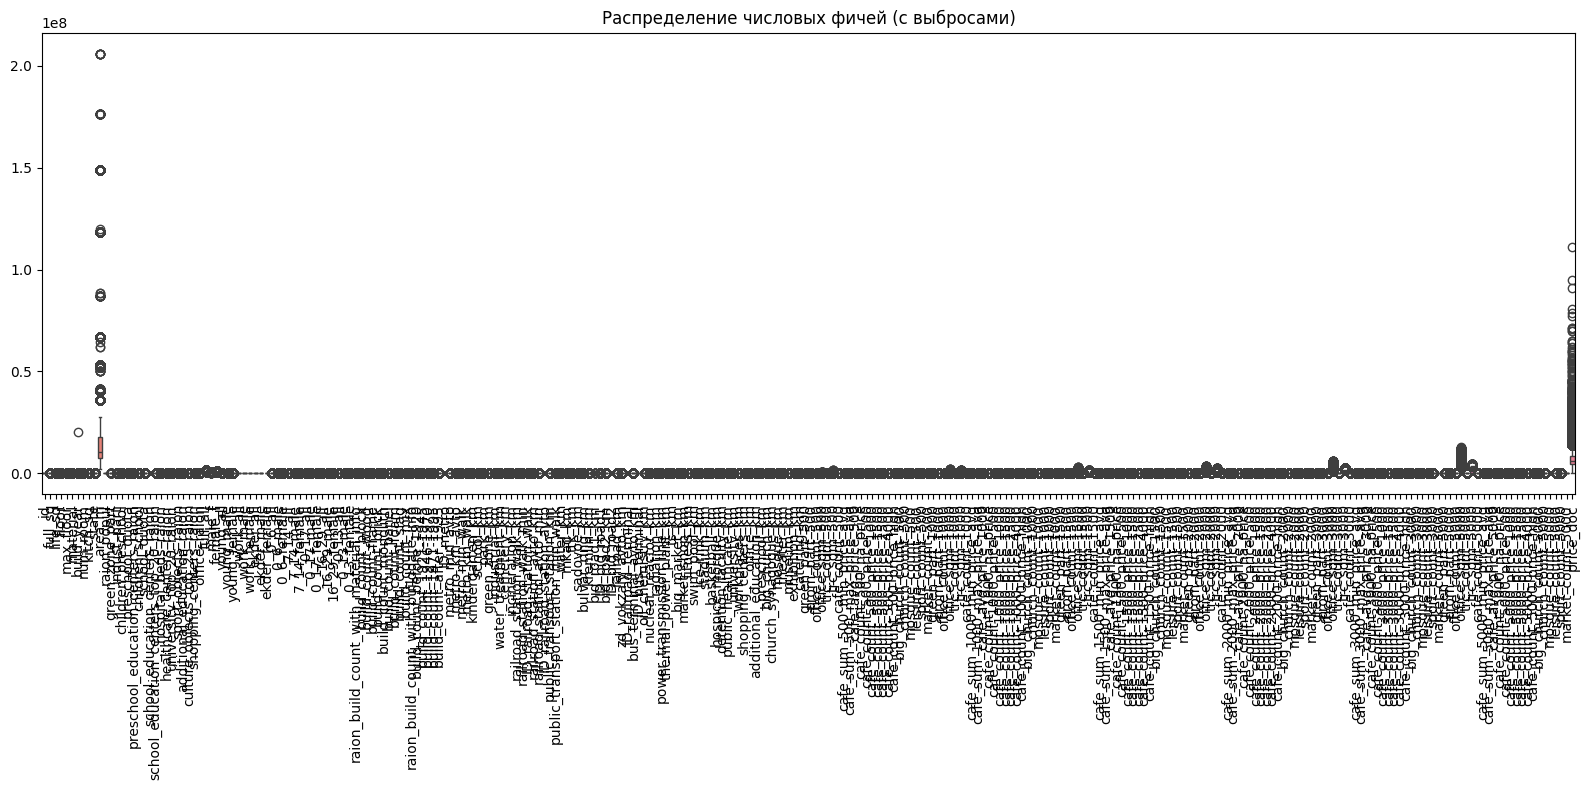

In [31]:
import matplotlib.pyplot as plt


# Смотрим на выбросы
plt.figure(figsize=(16, 8))
sns.boxplot(data=df_train[numeric_features])
plt.xticks(rotation=90)
plt.title('Распределение числовых фичей (с выбросами)')
plt.tight_layout()
plt.show()

In [32]:
from sklearn.preprocessing import RobustScaler


# x_scaled = (x - median) / IQR

# - median = 50-й процентиль
# - IQR = Q3 - Q1 (интерквартильный размах)
# - Большинство данных будет в диапазоне [-3, 3]
# - Но выбросы могут давать значения до ±10-20


robust_scaler = RobustScaler()
df_train[numeric_features] = robust_scaler.fit_transform(df_train[numeric_features])

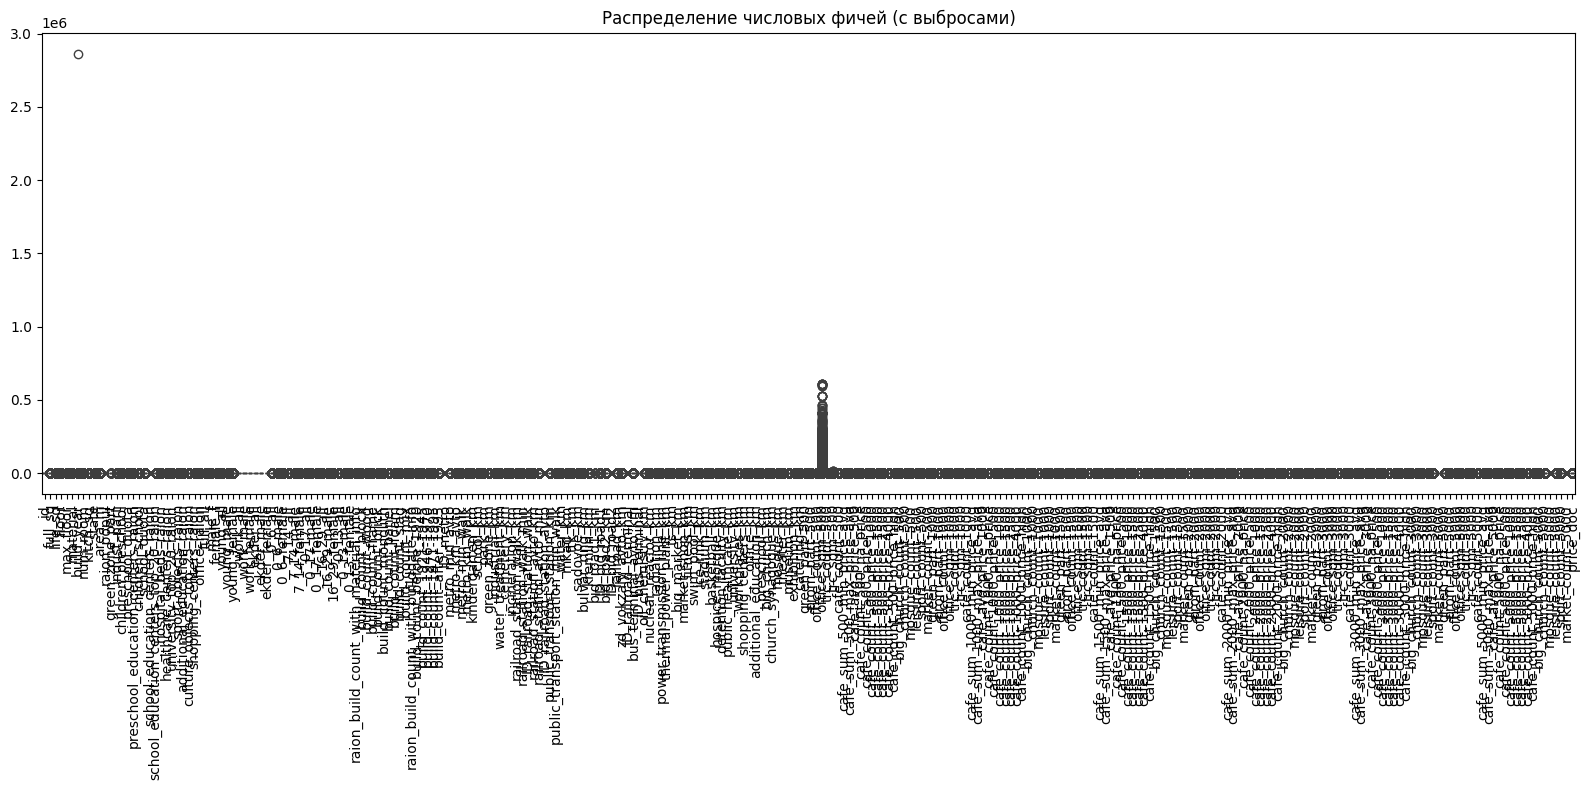

In [33]:
import matplotlib.pyplot as plt


# Смотрим на выбросы
plt.figure(figsize=(16, 8))
sns.boxplot(data=df_train[numeric_features])
plt.xticks(rotation=90)
plt.title('Распределение числовых фичей (с выбросами)')
plt.tight_layout()
plt.show()

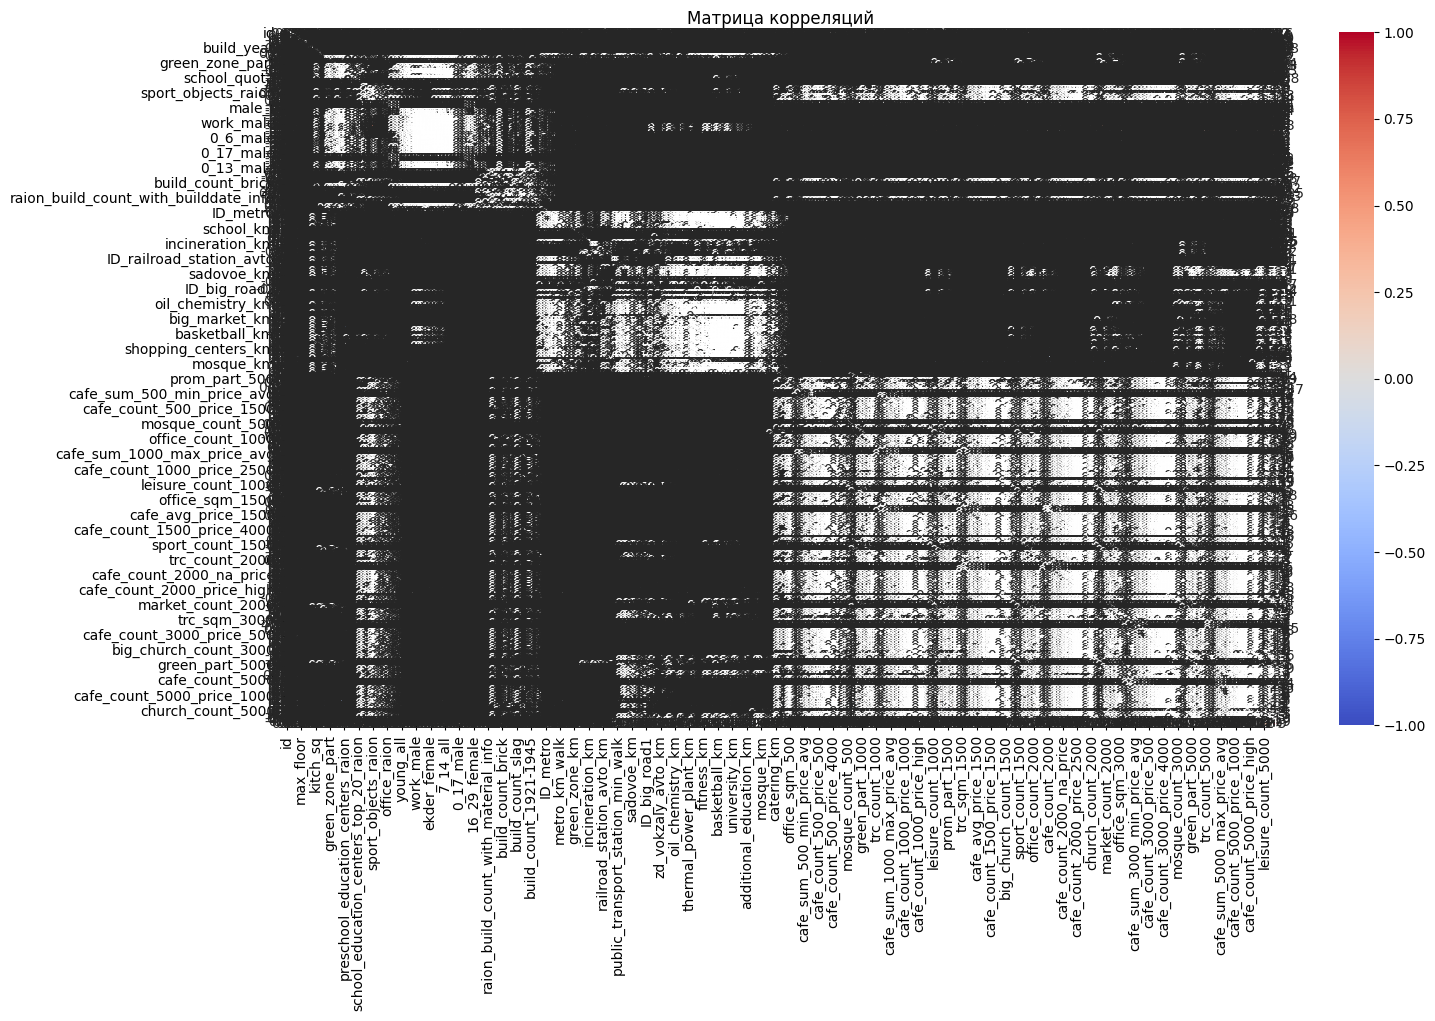

In [263]:
corr_matrix = df_train[numeric_features].corr()


plt.figure(figsize=(16, 9))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Матрица корреляций')

plt.show()


In [34]:
def rm_corr_features(df, numeric_features, threshold=0.9):
    '''Удаляю высокоррелирующие фичи'''

    corr_matrix = df[numeric_features].corr().abs()

    upper_triangle = corr_matrix.where(
        np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    )


    to_drop = [
        column for column in upper_triangle.columns
        if any(upper_triangle[column] > threshold)
    ]

    print(f'удаляем {len(to_drop)} фичей с порогом > {threshold}')

    features_to_keep = [f for f in numeric_features if f not in to_drop]

    print(f'осталось: {len(features_to_keep)} из {len(numeric_features)}')

    return features_to_keep, to_drop

In [35]:
numeric_features_filtered, dropped_features = rm_corr_features(
    df_train, numeric_features, threshold=0.95
)

удаляем 113 фичей с порогом > 0.95
осталось: 163 из 276


уже намного лучше! Было слишкком много фичей, которые коррелировали друг с другом слишком хорошо 

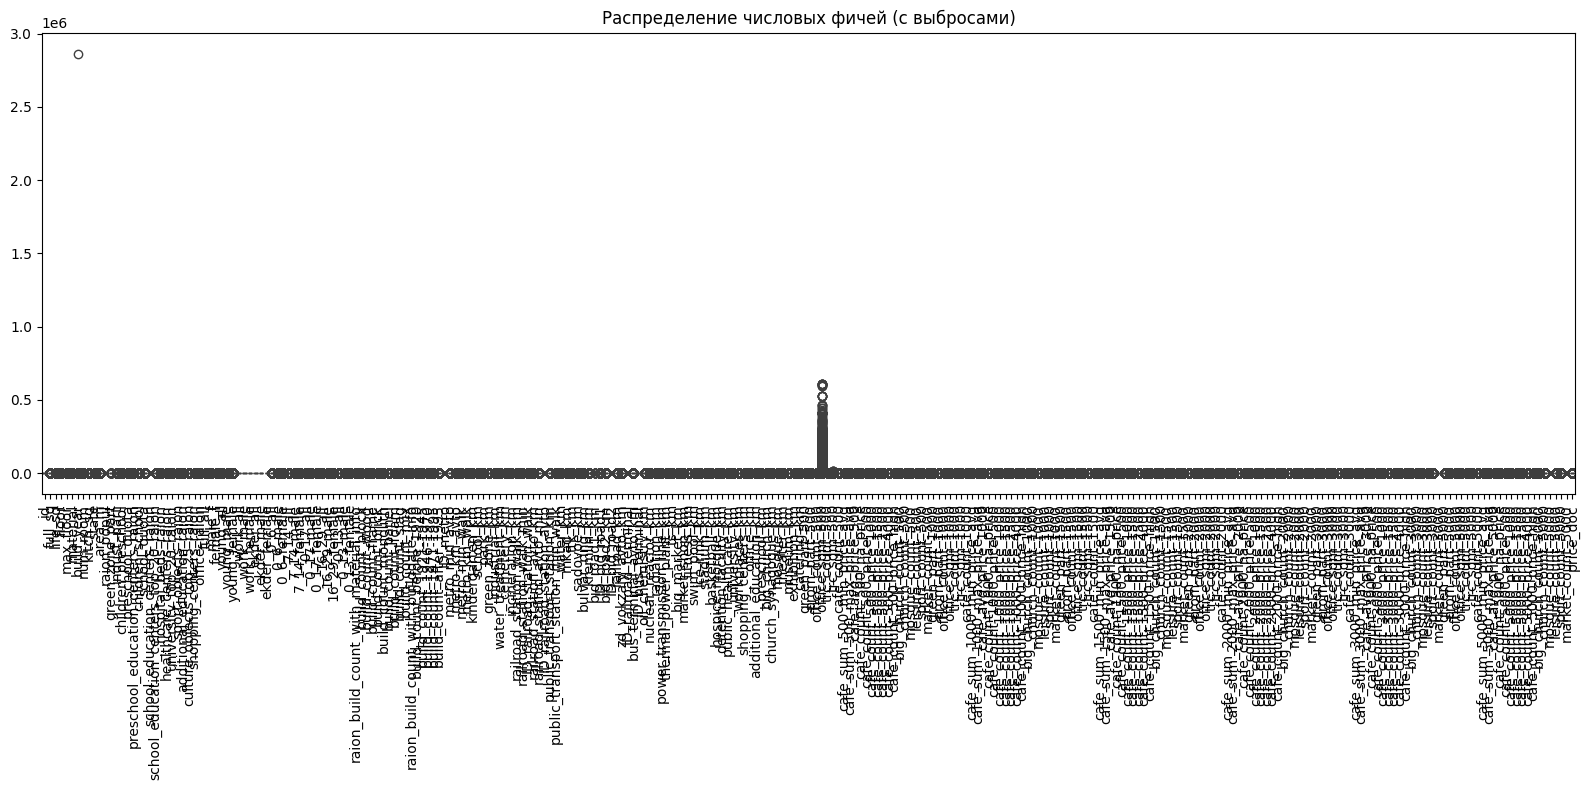

In [270]:
import matplotlib.pyplot as plt


# Смотрим на выбросы
plt.figure(figsize=(16, 8))
sns.boxplot(data=df_train[numeric_features])
plt.xticks(rotation=90)
plt.title('Распределение числовых фичей (с выбросами)')
plt.tight_layout()
plt.show()

Создам пайплайн

In [39]:
df_train_pip = pd.read_csv('train.csv')
df_test_pip = pd.read_csv('test.csv')



X_train = df_train_pip.drop('price_doc', axis=1)  # все колонки кроме целевой
X_train = preprocess_timestamp_pipeline(X_train)
y_train = df_train_pip['price_doc']      

X_test = df_test_pip   # для test датасета
X_test = preprocess_timestamp_pipeline(X_test)


In [40]:
categorical_features = X_train.select_dtypes(include=['object'])
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()



In [41]:
def cat_f(categorical_features_cols):
    date_col = [col for col in categorical_features_cols if col == 'timestamp']
    categorical_features_cols = [col for col in categorical_features_cols if col != 'timestamp']
    # Убираем дату - оченидно, что её нужно обрабатывать отдельно
    binary_cols = []  # для yes/no
    ordinal_cols = []  # для порядковых типо ecology


    for col in categorical_features_cols:
        unique_vals = df_train[col].unique()

        print('==============')
        print(f'Колонка: {col}')
        print(f'Уникальных значений: {len(unique_vals)}\n')
        if len(unique_vals) == 2:
            binary_cols.append(col)
            continue
        if len(unique_vals) < 15:  # считаю, что 15 - это оптимально
            ordinal_cols.append(col)

    large_categorial = [col for col in categorical_features_cols if col not in binary_cols and col not in date_col and col not in ordinal_cols]
            
    return date_col, binary_cols, ordinal_cols, large_categorial

In [42]:
date_col, binary_cols, ordinal_cols, large_categorial = cat_f(categorical_features)

Колонка: product_type
Уникальных значений: 2

Колонка: sub_area
Уникальных значений: 146

Колонка: culture_objects_top_25
Уникальных значений: 2

Колонка: thermal_power_plant_raion
Уникальных значений: 2

Колонка: incineration_raion
Уникальных значений: 2

Колонка: oil_chemistry_raion
Уникальных значений: 2

Колонка: radiation_raion
Уникальных значений: 2

Колонка: railroad_terminal_raion
Уникальных значений: 2

Колонка: big_market_raion
Уникальных значений: 2

Колонка: nuclear_reactor_raion
Уникальных значений: 2

Колонка: detention_facility_raion
Уникальных значений: 2

Колонка: water_1line
Уникальных значений: 2

Колонка: big_road1_1line
Уникальных значений: 2

Колонка: railroad_1line
Уникальных значений: 2

Колонка: ecology
Уникальных значений: 5



In [43]:
from sklearn.preprocessing import OneHotEncoder, TargetEncoder

In [44]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.9):
        self.threshold = threshold
        self.to_drop_ = None
    
    def fit(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            corr_matrix = X.corr().abs()
            upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
            self.to_drop_ = [col for col in upper_triangle.columns if any(upper_triangle[col] > self.threshold)]
        else:
            self.to_drop_ = []
        return self
    
    def transform(self, X):
        if self.to_drop_:
            if isinstance(X, pd.DataFrame):
                return X.drop(columns=self.to_drop_)
            else:
                raise ValueError('надо DataFrame')
        return X

In [45]:
from sklearn.preprocessing import FunctionTransformer

In [48]:
binary_transformer = Pipeline(steps=[
    ('binary', BinaryTransformer())
])

# timestamp_transformer = Pipeline(steps=[
#     ('timestamp', TimestampTransformer())
# ])

# Для ecology использую кастомную оценку с кастом трансформера
ecology_transformer = Pipeline(steps=[
    ('ordinal', EconomyTransformer())  
])

large_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, max_categories=20))
])

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('outlier_clipper', FunctionTransformer(lambda X: np.clip(X, -10, 10))),
    ('scaler', RobustScaler()),
    ('correlation_filter', CorrelationFilter())
])

In [49]:
from sklearn.compose import ColumnTransformer


preprocessor = ColumnTransformer(
    transformers=[
        ('binary', binary_transformer, binary_cols),
        # ('timestamp', timestamp_transformer, date_col),
        ('ordinal', ecology_transformer, ordinal_cols),
        ('large', large_transformer, large_categorial),
        ('numeric', numeric_transformer, numeric_features)
    ],
    remainder='passthrough'
)

## Полносвязная модель keras

In [50]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [51]:
np.random.seed(42)

In [52]:
preprocessor.fit(X_train)

,transformers,"[('binary', ...), ('ordinal', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,False


In [ ]:

X_sample_preprocessed = preprocessor.transform(X_train[:100])

print(f"форма: {X_sample_preprocessed.shape}:")
print(X_sample_preprocessed[:5]) 

форма: (100, 315):
[[ 1.   0.   0.  ...  1.5  0.5  1. ]
 [ 1.   1.   0.  ... -0.5  0.5  0. ]
 [ 1.   0.   0.  ...  1.5  0.5  1. ]
 [ 1.   0.   0.  ...  0.5  0.5  0. ]
 [ 1.   0.   0.  ... -1.   0.5  0. ]]


d:\политех\3 курс\ML\ilia\MLenv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
d:\политех\3 курс\ML\ilia\MLenv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [55]:
from keras import regularizers


model = keras.Sequential([

    layers.Dense(64, activation='relu', 
                kernel_regularizer=regularizers.l2(0.1), 
                kernel_initializer='he_normal',
                input_shape=(X_sample_preprocessed.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(32, activation='relu', 
                kernel_regularizer=regularizers.l2(0.1),
                kernel_initializer='he_normal'),
    
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    
    layers.Dense(1, activation='linear')
])

print('модель создана оу ес')

d:\политех\3 курс\ML\ilia\MLenv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


модель создана оу ес


пайплайн(

In [ ]:
from sklearn.base import BaseEstimator, RegressorMixin
from keras.optimizers import Adam


class SimpleWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, keras_model, epochs=50, batch_size=32, learning_rate=0.0001):
        self.keras_model = keras_model
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
    
    def fit(self, X, y):

        optimizer = Adam(
            learning_rate=self.learning_rate,
            clipnorm=1.0,
            beta_1=0.9,
            beta_2=0.999
        )

        self.keras_model.compile(
            optimizer=optimizer,
            loss='mse',
            metrics=['mae']
        )

        early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor='loss',
            patience=10,
            restore_best_weights=True
        )

        self.keras_model.fit(X, y, epochs=self.epochs, batch_size=self.batch_size, verbose=1, callbacks=[early_stopping])
        return self
    
    def predict(self, X):
        # предсказания в log
        predictions = self.keras_model.predict(X, verbose=0).flatten()

        # возвращаем нормальные значения
        return np.expm1(predictions) 

In [68]:
wrapped_model = SimpleWrapper(model, epochs=100, batch_size=32, learning_rate=0.0001)

In [58]:
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', wrapped_model)
])

print('gotovo')

gotovo


встретил проблему взрыва градиента, да так, что сразу вместо метрик мне выдали nan!


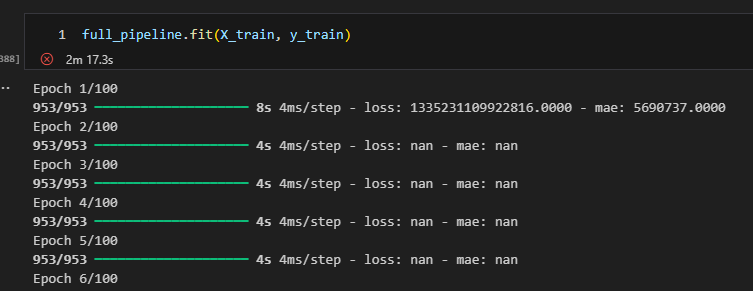

вследствие чего было принято решение логарифмировать целевую колонку

In [ ]:
y_train_log = np.log1p(y_train)

потом так же решил пересобрать модели и сильно уменьшить количество нейронов. Метрики немного ухудшились, но не значительно (на 0.4)

In [67]:
full_pipeline.fit(X_train, y_train_log)

Epoch 1/100
953/953 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 6783.1821 - mae: 77.4680
Epoch 2/100
953/953 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4839.9614 - mae: 67.8187
Epoch 3/100
953/953 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 3616.0911 - mae: 58.6052
Epoch 4/100
953/953 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2659.7236 - mae: 50.1814
Epoch 5/100
953/953 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1890.0265 - mae: 42.2137
Epoch 6/100
953/953 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1284.9044 - mae: 34.7096
Epoch 7/100
953/953 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 839.4341 - mae: 27.9362
Epoch 8/100
953/953 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 510.1624 - mae: 21.5973
Epoch 9/100
953/953 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 280.3302 - mae: 15.8364
Epoch 10/100
953/953 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 134.3555 - mae: 10.7279
Epoch 11/100
953/953 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 50.3514 - mae: 6.2149
Epoch 12/100
953/953 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - los

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('binary', ...), ('ordinal', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


~~MAE 0.9743~~ **MAE: 0.6358**

In [69]:
test_pred = full_pipeline.predict(X_test)

d:\политех\3 курс\ML\ilia\MLenv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
d:\политех\3 курс\ML\ilia\MLenv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
d:\политех\3 курс\ML\ilia\MLenv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [70]:
submission = pd.DataFrame({
    'id': df_test_pip['id'],
    'price_doc': test_pred
})

submission.to_csv('submission_TEST_KILL.csv', index=False)
print("submission создан!!!!!")
print(f"Предсказания: min={test_pred.min():.2f}, max={test_pred.max():.2f}")

submission создан!!!!!
Предсказания: min=2610115.00, max=22737012.00


In [76]:
model.get_build_config()

{'input_shape': (None, 315)}

In [77]:
model.get_compile_config()

{'optimizer': {'module': 'keras.optimizers',
  'class_name': 'Adam',
  'config': {'name': 'adam',
   'learning_rate': 9.999999747378752e-05,
   'weight_decay': None,
   'clipnorm': 1.0,
   'global_clipnorm': None,
   'clipvalue': None,
   'use_ema': False,
   'ema_momentum': 0.99,
   'ema_overwrite_frequency': None,
   'loss_scale_factor': None,
   'gradient_accumulation_steps': None,
   'beta_1': 0.9,
   'beta_2': 0.999,
   'epsilon': 1e-07,
   'amsgrad': False},
  'registered_name': None},
 'loss': 'mse',
 'loss_weights': None,
 'metrics': ['mae'],
 'weighted_metrics': None,
 'run_eagerly': False,
 'steps_per_execution': 1,
 'jit_compile': False}

In [78]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,781 (264.77 KB)

 Trainable params: 22,529 (88.00 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 45,060 (176.02 KB)